In [1]:
import pandas as pd
import numpy as np
import re, html
import tensorflow as tf
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)
import matplotlib.pyplot as plt
import seaborn as sns
import os, pickle


In [2]:
os.makedirs("model", exist_ok=True)
os.makedirs("results", exist_ok=True)

In [3]:
df = pd.read_csv(r"C:\Users\ASUS\Documents\archive (4)\IMDB Dataset.csv")
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


EDA

Shape: (50000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 781.4+ KB

Missing values per column:
review       0
sentiment    0
dtype: int64

Duplicate rows: 418

Label distribution counts:
sentiment
1    25000
0    25000
Name: count, dtype: int64

Label distribution percent:
sentiment
1    0.5
0    0.5
Name: proportion, dtype: float64


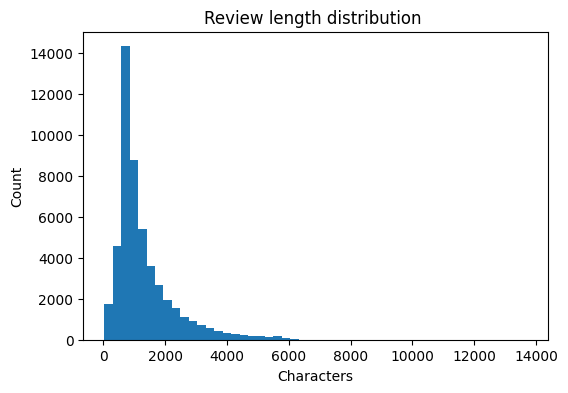

In [4]:
print('Shape:', df.shape)
df.info()

print("\nMissing values per column:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nLabel distribution counts:")
print(df['sentiment'].value_counts())
print("\nLabel distribution percent:")
print(df['sentiment'].value_counts(normalize=True).round(4))

df['review_len'] = df['review'].astype(str).str.len()
plt.figure(figsize=(6,4))
plt.hist(df['review_len'], bins=50)
plt.title('Review length distribution ')
plt.xlabel('Characters')
plt.ylabel('Count')
plt.show()


In [5]:
def clean_text(text: str) -> str:
    text = str(text)
    text = html.unescape(text)
    text = text.lower()
  
    text = re.sub(r'<br\s*/?>', ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['review_clean'] = df['review'].apply(clean_text)
df[['review','review_clean']].head()


,review,review_clean
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production. the filming tec...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...","petter mattei's ""love in the time of money"" is..."


In [6]:
analyzer = SentimentIntensityAnalyzer()

def extract_features(text):
    vader = analyzer.polarity_scores(text)
    blob = TextBlob(text).sentiment.polarity
    return pd.Series([vader['neg'], vader['neu'], vader['pos'], vader['compound'], blob])

df[['vader_neg','vader_neu','vader_pos','vader_compound','textblob_polarity']] = df['review_clean'].apply(extract_features)


Training and test splitting 

In [7]:
y = df['sentiment']

X = df[['vader_neg', 'vader_neu', 'vader_pos', 'vader_compound', 'textblob_polarity']]
X_text = df["review_clean"]
X_temp, X_test, X_temp_text, X_test_text, y_temp, y_test = train_test_split(
    X, X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_temp, X_temp_text, y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


mlp.fit(X_train_scaled, y_train)


mlp_preds = mlp.predict(X_test_scaled)

Training our MLP

In [12]:
mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    solver="adam",
    max_iter=300,
    random_state=42
)

mlp.fit(X_train, y_train)


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(16, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",300
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [15]:

train_proba = mlp.predict_proba(X_train)[:, 1]
val_proba   = mlp.predict_proba(X_val)[:, 1]
test_proba  = mlp.predict_proba(X_test)[:, 1]

y_train_pred = (train_proba >= 0.5).astype(int)
val_pred     = (val_proba   >= 0.5).astype(int)
y_test_pred  = (test_proba  >= 0.5).astype(int)

train_acc = accuracy_score(y_train, y_train_pred)
val_acc   = accuracy_score(y_val, val_pred)
test_acc  = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Test Accuracy:", test_acc)

print("\nClassification Report (TEST):\n")
print(classification_report(y_test, y_test_pred))

with open("results/metrics.txt", "w") as f:
    f.write(f"Training Accuracy: {train_acc}\n")
    f.write(f"Validation Accuracy: {val_acc}\n")
    f.write(f"Test Accuracy: {test_acc}\n\n")
    f.write(classification_report(y_test, y_test_pred))


Training Accuracy: 0.7513
Validation Accuracy: 0.7523
Test Accuracy: 0.7541

Classification Report (TEST):

              precision    recall  f1-score   support

           0       0.81      0.66      0.73      5000
           1       0.71      0.85      0.78      5000

    accuracy                           0.75     10000
   macro avg       0.76      0.75      0.75     10000
weighted avg       0.76      0.75      0.75     10000



C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(
C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(
C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(


Plotting the Confusion Matrix 

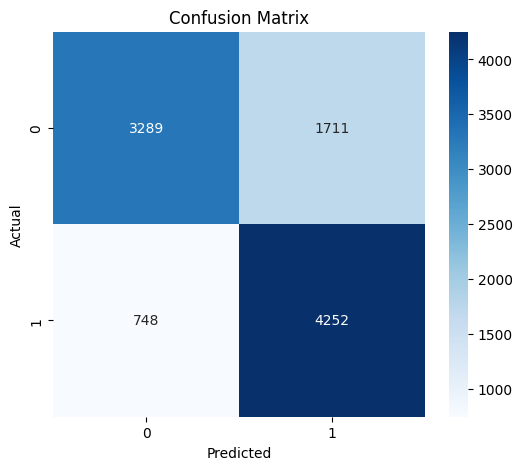

In [16]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("results/confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()


Plotting the loss Curve

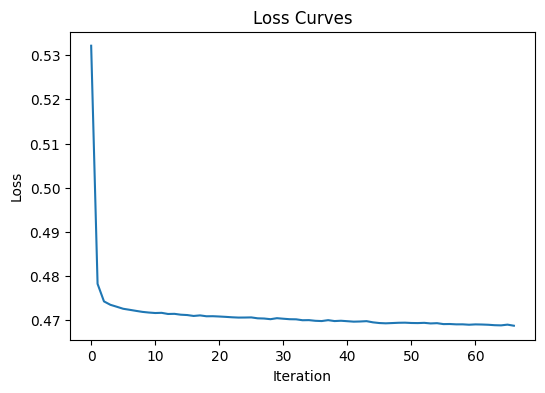

In [17]:
plt.figure(figsize=(6,4))
plt.plot(mlp.loss_curve_)
plt.title("Loss Curves")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.savefig("results/loss_curves.png", dpi=200, bbox_inches="tight")
plt.show()


In [18]:


from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 20000
max_len = 200

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)   

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq   = tokenizer.texts_to_sequences(X_val_text)
X_test_seq  = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_val_pad   = pad_sequences(X_val_seq, maxlen=max_len, padding='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

In [19]:


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

lstm_model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 86s 111ms/step - accuracy: 0.5915 - loss: 0.6495 - val_accuracy: 0.5960 - val_loss: 0.6454 - learning_rate: 0.0010
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 103s 137ms/step - accuracy: 0.7435 - loss: 0.5096 - val_accuracy: 0.7492 - val_loss: 0.5128 - learning_rate: 0.0010
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 128s 171ms/step - accuracy: 0.8300 - loss: 0.4212 - val_accuracy: 0.8155 - val_loss: 0.4647 - learning_rate: 0.0010
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 136s 181ms/step - accuracy: 0.8584 - loss: 0.3612 - val_accuracy: 0.8285 - val_loss: 0.4098 - learning_rate: 0.0010
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 138s 184ms/step - accuracy: 0.8766 - loss: 0.3051 - val_accuracy: 0.8318 - val_loss: 0.4148 - learning_rate: 0.0010
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 139s 186ms/step - accuracy: 0.8246 - loss: 0.3834 - val_accuracy: 0.8662 - val_loss: 0.3504 - learning_rate: 0.0010
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 138s 181ms/step - accurac

In [20]:
from sklearn.metrics import accuracy_score, classification_report

lstm_preds = (lstm_model.predict(X_test_pad) > 0.5).astype(int)

print("LSTM Accuracy:", accuracy_score(y_test, lstm_preds))
print(classification_report(y_test, lstm_preds))

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step
LSTM Accuracy: 0.8659
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      5000
           1       0.88      0.85      0.86      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [30]:
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D

cnn_model = Sequential([
    Embedding(10000, 100, input_shape=(100,)),
    Conv1D(128, 5, activation="relu"),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

cnn_model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)              │ (None, 100, 100)            │       1,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_4 (Conv1D)                    │ (None, 96, 128)             │          64,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d_4               │ (None, 128)                 │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,068,289 (4.08 MB)

 Trainable params: 1,068,289 (4.08 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:


from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D

cnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

cnn_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=8,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 116s 240ms/step - accuracy: 0.7999 - loss: 0.4089 - val_accuracy: 0.8959 - val_loss: 0.2589
Epoch 2/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 144s 245ms/step - accuracy: 0.9380 - loss: 0.1707 - val_accuracy: 0.8893 - val_loss: 0.2665


In [32]:

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(X_test, y_test)

print("CNN Test Loss:", cnn_test_loss)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5000 - loss: 0.8413
CNN Test Loss: 0.8412642478942871
CNN Test Accuracy: 0.5


Saving the  model

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout

gru_model = Sequential([
    Embedding(input_dim=10000, output_dim=100, input_shape=(100,)),
    GRU(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

gru_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_model.summary()

C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (None, 100, 100)            │       1,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 64)                  │          31,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,033,985 (3.94 MB)

 Trainable params: 1,033,985 (3.94 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout

gru_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    GRU(64),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

gru_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=8,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/8


C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


469/469 ━━━━━━━━━━━━━━━━━━━━ 169s 344ms/step - accuracy: 0.5886 - loss: 0.6448 - val_accuracy: 0.6618 - val_loss: 0.6136
Epoch 2/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 160s 341ms/step - accuracy: 0.8733 - loss: 0.3091 - val_accuracy: 0.8961 - val_loss: 0.2588


In [38]:
gru_test_loss, gru_test_acc = gru_model.evaluate(X_test, y_test)

print("GRU Test Loss:", gru_test_loss)
print("GRU Test Accuracy:", gru_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5000 - loss: 0.7000
GRU Test Loss: 0.6999878287315369
GRU Test Accuracy: 0.5


In [25]:
with open("model/best_model.pkl", "wb") as f:
    pickle.dump(mlp, f)


getting submiossion.csv

In [13]:
all_proba = mlp.predict_proba(X)[:, 1]
all_pred  = (all_proba >= 0.5).astype(int)

submission = pd.DataFrame({
    "review": df["review"],
    "predicted_sentiment": all_pred
})

submission.to_csv("submission.csv", index=False)
submission.head()



,review,predicted_sentiment
0,One of the other reviewers has mentioned that ...,0
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


Discussion
. the dataset has been split into: 60% training set, 20% validation test and 20% test set 
.The reslts showcast an accuracy of 77.32% for both training and test with a an accuracy of 77.36% for validation
.These results above showcast thta the perfirmance is reasinable yet limited. A limitatipn that is due to the polarity scores used that do not capture all aspecys like sarcasm for exemple


In [39]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

mlp_preds = mlp.predict(X_test_scaled)
mlp_acc = accuracy_score(y_test, mlp_preds)
mlp_f1 = f1_score(y_test, mlp_preds)

lstm_preds = (lstm_model.predict(X_test_pad) > 0.5).astype(int).ravel()
lstm_acc = accuracy_score(y_test, lstm_preds)
lstm_f1 = f1_score(y_test, lstm_preds)

gru_preds = (gru_model.predict(X_test_pad) > 0.5).astype(int).ravel()
gru_acc = accuracy_score(y_test, gru_preds)
gru_f1 = f1_score(y_test, gru_preds)

cnn_preds = (cnn_model.predict(X_test_pad) > 0.5).astype(int).ravel()
cnn_acc = accuracy_score(y_test, cnn_preds)
cnn_f1 = f1_score(y_test, cnn_preds)

results = [
    ["MLP Baseline", mlp_acc, mlp_f1],
    ["LSTM", lstm_acc, lstm_f1],
    ["GRU", gru_acc, gru_f1],
    ["1D CNN", cnn_acc, cnn_f1]
]

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1"])
print(results_df)

313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step
          Model  Accuracy        F1
0  MLP Baseline    0.7823  0.783491
1          LSTM    0.8659  0.863345
2           GRU    0.6683  0.726883
3        1D CNN    0.8945  0.895140


In [40]:
lstm_results_df = pd.DataFrame({
    "true_label": y_test,
    "predicted_label": lstm_preds
})

lstm_results_df.to_csv("lstm_results.csv", index=False)

In [41]:
cnn_preds = (cnn_model.predict(X_test_pad) > 0.5).astype(int).ravel()
cnn_results_df = pd.DataFrame({
    "true_label": y_test,
    "predicted_label": cnn_preds
})

cnn_results_df.to_csv("cnn_results.csv", index=False)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step


In [42]:
mlp_results_df = pd.DataFrame({
    "true_label": y_test,
    "predicted_label": mlp_preds
})

mlp_results_df.to_csv("mlp_results.csv", index=False)

In [43]:
gru_results_df = pd.DataFrame({
    "true_label": y_test,
    "predicted_label": gru_preds
})

gru_results_df.to_csv("gru_results.csv", index=False)